# Weakly Supervised Maske Doğrulama Analizi

**Bilgi.xlsx** gerçek annotasyonları ile **üretilen 3D maskeleri** karşılaştırır.

| Kavram | Kaynak | İçerik |
|--------|--------|--------|
| Gerçek konum | Bilgi.xlsx BB | 2D bounding box (hastalık tam yeri) |
| Gerçek z-aralık | Bilgi.xlsx Boundary Slice | Organın başlangıç/bitiş kesiti |
| Tahmin | weak_seg NIfTI | 3D hastalık maskesi |

## Metrikler
- **BB Coverage (Recall):** BB piksellerinin kaçı maskede var?
- **Mask Precision:** Maskeli piksellerin kaçı BB içinde?
- **Z-range IoU:** Maske z-aralığı ile Boundary Slice uyumu

In [1]:
import sys
from pathlib import Path

PROJECT = Path('abdomen_project')
sys.path.insert(0, str(PROJECT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import SimpleITK as sitk

from src.config import RAW_TRAIN_DIR, RAW_TEST_DIR, SUPER_CLASSES
from src.dicom_utils import load_series, window_hu, Window

MASK_DIR  = PROJECT / 'outputs' / 'seg_data' / 'weak_disease_masks'
BILGI_XLS = Path('Bilgi.xlsx')

COLORS = {
    1:'#e74c3c', 2:'#3498db', 3:'#2ecc71',
    4:'#f39c12', 5:'#9b59b6', 6:'#1abc9c'
}
SOFT_WIN = Window('soft_tissue', level=40, width=400)

print('Hazır.')

Hazır.


## 1. Veri Yükleme

In [2]:
# Bilgi.xlsx — her iki sayfa
sheets   = pd.read_excel(BILGI_XLS, sheet_name=None)
all_ann  = pd.concat([
    sheets['TRAIININGDATA'].assign(source='train'),
    sheets['COMPETITIONDATA'].assign(source='comp'),
], ignore_index=True)

# Manifest
manifest = pd.read_csv(PROJECT / 'outputs' / 'splits' / 'manifest.csv')

# Mevcut maskeler
mask_files = sorted(MASK_DIR.glob('*_disease.nii.gz'))
case_ids   = [int(p.stem.split('_')[1]) for p in mask_files]

print(f'Toplam maske: {len(mask_files)}')
for cid in case_ids:
    print(f'  case {cid}')
print(f'Toplam annotasyon satiri: {len(all_ann):,}')

Toplam maske: 5
  case 20001
  case 20002
  case 20003
  case 20004
  case 20005
Toplam annotasyon satiri: 42,448


## 2. Yardımcı Fonksiyonlar

In [3]:
from src.config import RAW_PATHOLOGY_TO_SUPER, ANATOMICAL_TO_ID

def find_case_dir(case_id):
    for base in (RAW_TRAIN_DIR, RAW_TEST_DIR):
        d = base / str(case_id)
        if d.is_dir():
            return d
    return None

def parse_bb_str(raw):
    """'x1,y1-x2,y2' → (x1,y1,x2,y2) veya None"""
    try:
        a, b = raw.split('-')
        x1,y1 = map(int, a.split(','))
        x2,y2 = map(int, b.split(','))
        return (x1,y1,x2,y2) if x2>x1 and y2>y1 else None
    except:
        return None

def bb_mask(bb, shape):
    """BB koordinatlarından 2D binary maske (H,W)"""
    m = np.zeros(shape, dtype=np.uint8)
    x1,y1,x2,y2 = bb
    m[y1:y2, x1:x2] = 1
    return m

def load_case_annotations(case_id, all_ann):
    """Bilgi.xlsx'ten BB ve Boundary Slice bilgilerini döndürür."""
    rows = all_ann[all_ann['Case Number'] == case_id].copy()
    bb_rows  = rows[rows['Type'] == 'Bounding Box'].copy()
    bsl_rows = rows[rows['Type'] == 'Boundary Slice'].copy()

    # BB: {image_id: [(super_id, x1,y1,x2,y2), ...]}
    bb_by_img = {}
    for _, r in bb_rows.iterrows():
        bb = parse_bb_str(str(r['Data']))
        if bb is None:
            continue
        sid = RAW_PATHOLOGY_TO_SUPER.get(r['Class'])
        if sid is None:
            continue
        bb_by_img.setdefault(int(r['Image Id']), []).append((sid, *bb))

    # Boundary Slice: {organ: (z_lo_imgid, z_hi_imgid)}
    bsl_by_organ = {}
    for organ, grp in bsl_rows.groupby('Class'):
        ids = sorted(grp['Image Id'].astype(int).tolist())
        bsl_by_organ[organ] = (ids[0], ids[-1])

    return bb_by_img, bsl_by_organ

print('Fonksiyonlar hazir.')

Fonksiyonlar hazir.


## 3. Tek Vaka Detay Analizi

In [4]:
CASE_ID = 20001   # <-- değiştirilebilir

mask_path = MASK_DIR / f'ABE_{CASE_ID:05d}_disease.nii.gz'
assert mask_path.exists(), f'Maske yok: {mask_path}'

case_dir = find_case_dir(CASE_ID)
assert case_dir, f'DICOM dizini bulunamadi: {CASE_ID}'

# Yükle
series   = load_series(case_dir)
mask_arr = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_path)))
idx_of   = {img_id: i for i, img_id in enumerate(series.image_ids)}

bb_by_img, bsl_by_organ = load_case_annotations(CASE_ID, all_ann)

print(f'Case {CASE_ID}')
print(f'  CT shape  : {series.hu.shape}  spacing_z={series.spacing_zyx[0]:.1f} mm')
print(f'  Mask shape: {mask_arr.shape}')
print(f'  BB annotasyonlu kesit: {len(bb_by_img)}')
print(f'  Boundary Slice organ: {list(bsl_by_organ.keys())}')
print()
print('Mask sinif dagilimi:')
for cid in range(1,7):
    n = (mask_arr==cid).sum()
    if n:
        zs = np.where(mask_arr.max(axis=(1,2))==cid)[0]
        print(f'  {SUPER_CLASSES[cid-1]:35s}: {n:>10,} voxel  z=[{zs.min()}-{zs.max()}]')

Case 20001
  CT shape  : (113, 512, 512)  spacing_z=5.0 mm
  Mask shape: (113, 512, 512)
  BB annotasyonlu kesit: 10
  Boundary Slice organ: ['Abdominal Aorta', 'Colon', 'Gall bladder', 'Kidney-Bladder', 'Pancreas', 'appendix']

Mask sinif dagilimi:
  kidney_ureter_stone                :    182,050 voxel  z=[6-90]
  acute_appendicitis                 :    131,195 voxel  z=[57-78]


## 4. BB Coverage & Mask Precision Metrikleri

In [5]:
# disease_id -> organ -> anatomical label
# cls_id = disease_id + 1

records = []
for img_id, bb_list in bb_by_img.items():
    z = idx_of.get(img_id)
    if z is None:
        continue
    mask_slice = mask_arr[z]

    for entry in bb_list:
        sid, x1, y1, x2, y2 = entry
        cls_id  = sid + 1
        cls_name = SUPER_CLASSES[sid].replace('_',' ')

        gt   = bb_mask((x1,y1,x2,y2), mask_slice.shape)  # BB piksel maskesi
        pred = (mask_slice == cls_id).astype(np.uint8)    # tahmin maskesi

        gt_px    = gt.sum()
        pred_px  = pred.sum()
        tp       = (gt & pred).sum()

        bb_cov  = tp / gt_px   if gt_px  > 0 else 0.0
        mask_pr = tp / pred_px if pred_px > 0 else 0.0

        records.append({
            'image_id' : img_id,
            'z'        : z,
            'class'    : cls_name,
            'BB_pixels': int(gt_px),
            'Mask_pixels': int(pred_px),
            'TP_pixels': int(tp),
            'BB_Coverage_%': round(bb_cov * 100, 1),
            'Mask_Precision_%': round(mask_pr * 100, 1),
        })

metrics_df = pd.DataFrame(records)
print(metrics_df[['image_id','z','class','BB_pixels','Mask_pixels','TP_pixels',
                   'BB_Coverage_%','Mask_Precision_%']].to_string(index=False))
print()
print('Ortalama BB Coverage  :', metrics_df['BB_Coverage_%'].mean().round(1), '%')
print('Ortalama Mask Precision:', metrics_df['Mask_Precision_%'].mean().round(1), '%')

 image_id  z               class  BB_pixels  Mask_pixels  TP_pixels  BB_Coverage_%  Mask_Precision_%
   100007  6 kidney ureter stone        132          132        132          100.0             100.0
   100008  7 kidney ureter stone        100          100        100          100.0             100.0
   100063 62  acute appendicitis        209          209        209          100.0             100.0
   100064 63  acute appendicitis        255          255        255          100.0             100.0
   100065 64  acute appendicitis        289          289        289          100.0             100.0
   100066 65  acute appendicitis        304          304        304          100.0             100.0
   100067 66  acute appendicitis        315          315        315          100.0             100.0
   100068 67  acute appendicitis        270          284        270          100.0              95.1
   100068 67  acute appendicitis        324          284         14            4.3         

## 5. Z-Range Uyum Analizi (Boundary Slice vs Maske)

In [6]:
from src.weak_seg import DISEASE_TO_ORGAN

# Ters mapping: organ_name -> [disease_id]
organ_to_disease = {}
for did, org in DISEASE_TO_ORGAN.items():
    organ_to_disease.setdefault(org, []).append(did)

zrange_records = []
for organ, (bsl_lo_id, bsl_hi_id) in bsl_by_organ.items():
    z_lo = idx_of.get(bsl_lo_id)
    z_hi = idx_of.get(bsl_hi_id)
    if z_lo is None or z_hi is None:
        continue

    for did in organ_to_disease.get(organ, []):
        cls_id = did + 1
        pred_z = np.where(mask_arr.max(axis=(1,2)) == cls_id)[0]
        if len(pred_z) == 0:
            continue
        pred_lo, pred_hi = pred_z.min(), pred_z.max()

        inter_lo = max(z_lo, pred_lo)
        inter_hi = min(z_hi, pred_hi)
        union_lo = min(z_lo, pred_lo)
        union_hi = max(z_hi, pred_hi)
        inter    = max(0, inter_hi - inter_lo + 1)
        union    = union_hi - union_lo + 1
        iou      = inter / union if union > 0 else 0.0

        zrange_records.append({
            'organ'  : organ,
            'disease': SUPER_CLASSES[did].replace('_',' '),
            'BSL_z'  : f'[{z_lo}-{z_hi}] ({z_hi-z_lo+1} kesit)',
            'Pred_z' : f'[{pred_lo}-{pred_hi}] ({pred_hi-pred_lo+1} kesit)',
            'Z_IoU_%': round(iou*100,1),
        })

zr_df = pd.DataFrame(zrange_records)
if len(zr_df):
    print(zr_df.to_string(index=False))
else:
    print('Bu vakada z-araligi eslesmesi bulunamadi.')

         organ             disease              BSL_z             Pred_z  Z_IoU_%
Kidney-Bladder kidney ureter stone  [9-90] (82 kesit)  [6-90] (85 kesit)     96.5
      appendix  acute appendicitis [57-78] (22 kesit) [57-78] (22 kesit)    100.0


## 6. Tüm BB Kesitlerini Görselleştir (CT | BB | Maske)

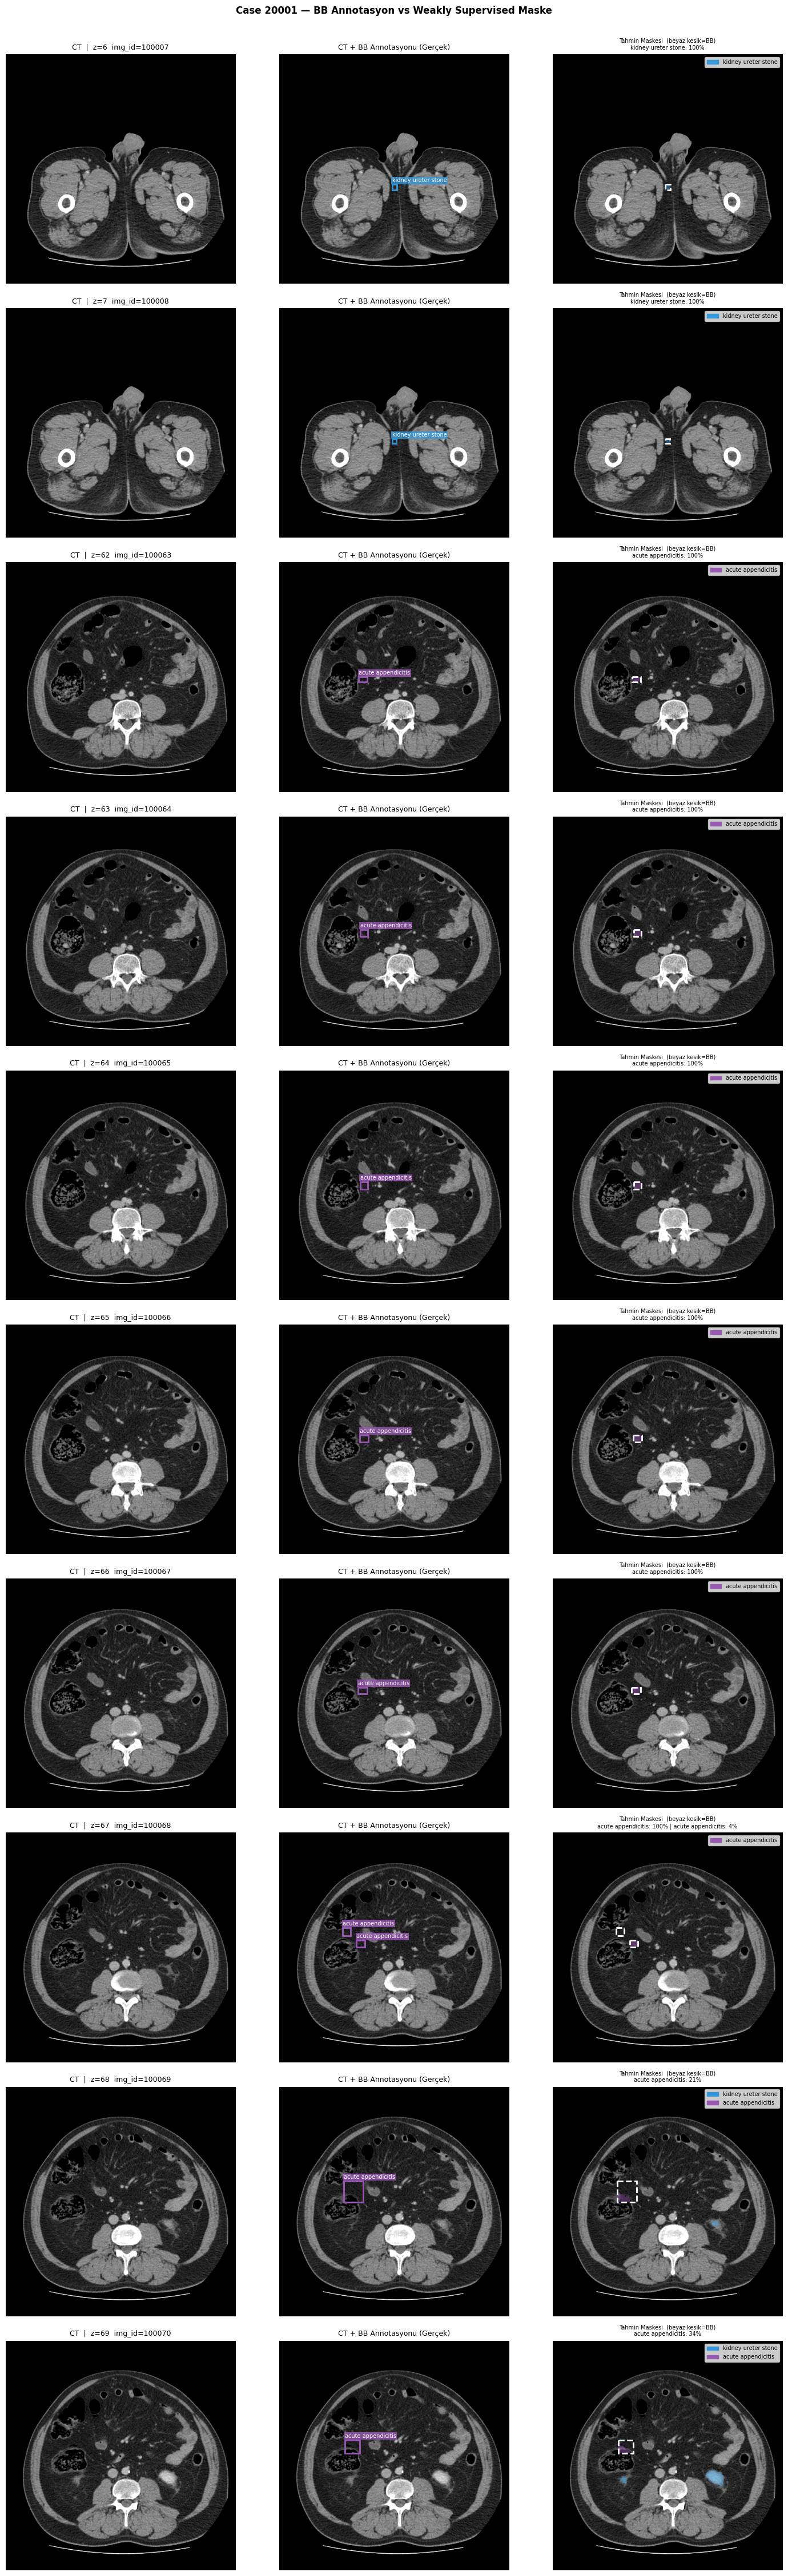

Kaydedildi.


In [7]:
%matplotlib inline
annotated_zs = sorted(set(
    idx_of[img_id] for img_id in bb_by_img if img_id in idx_of
))

n = len(annotated_zs)
fig, axes = plt.subplots(n, 3, figsize=(15, 4.5 * n))
if n == 1:
    axes = axes[np.newaxis, :]

for row_i, z in enumerate(annotated_zs):
    img_id     = series.image_ids[z]
    ct_slice   = window_hu(series.hu[z], SOFT_WIN)
    mask_slice = mask_arr[z]
    bbs       = bb_by_img.get(img_id, [])

    # Coverage hesapla bu z için
    cov_strs = []
    for sid,x1,y1,x2,y2 in bbs:
        gt   = np.zeros(mask_slice.shape, np.uint8); gt[y1:y2,x1:x2]=1
        pred = (mask_slice==sid+1).astype(np.uint8)
        tp   = (gt&pred).sum()
        cov  = tp/gt.sum()*100 if gt.sum() else 0
        cov_strs.append(f'{SUPER_CLASSES[sid].replace("_"," ")[:20]}: {cov:.0f}%')

    # ── (A) Ham CT ───────────────────────────────────────────────────────
    ax = axes[row_i, 0]
    ax.imshow(ct_slice, cmap='gray')
    ax.set_title(f'CT  |  z={z}  img_id={img_id}', fontsize=9)
    ax.axis('off')

    # ── (B) CT + BB (gerçek annotasyon) ──────────────────────────────────
    ax = axes[row_i, 1]
    ax.imshow(ct_slice, cmap='gray')
    for entry in bb_by_img.get(img_id, []):
        sid, x1, y1, x2, y2 = entry
        clr = COLORS.get(sid+1, 'red')
        rect = mpatches.Rectangle((x1,y1), x2-x1, y2-y1,
                                   lw=2, edgecolor=clr, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, max(y1-5,5), SUPER_CLASSES[sid].replace('_',' '),
                fontsize=7, color='white',
                bbox=dict(facecolor=clr, alpha=0.8, pad=1, edgecolor='none'))
    ax.set_title('CT + BB Annotasyonu (Gerçek)', fontsize=9)
    ax.axis('off')

    # ── (C) CT + Tahmin Maskesi ───────────────────────────────────────────
    ax = axes[row_i, 2]
    ax.imshow(ct_slice, cmap='gray')
    overlay = np.zeros((*ct_slice.shape, 4), dtype=np.float32)
    patches = []
    for cid, clr in COLORS.items():
        region = mask_slice == cid
        if not region.any():
            continue
        rgba = mcolors.to_rgba(clr)
        overlay[region] = (*rgba[:3], 0.50)
        patches.append(mpatches.Patch(color=clr,
                        label=SUPER_CLASSES[cid-1].replace('_',' ')))
    ax.imshow(overlay)
    # BB sınırını üste çiz (kıyaslama için)
    for entry in bb_by_img.get(img_id, []):
        sid, x1, y1, x2, y2 = entry
        rect = mpatches.Rectangle((x1,y1), x2-x1, y2-y1,
                                   lw=2, edgecolor='white',
                                   facecolor='none', linestyle='--')
        ax.add_patch(rect)
    if patches:
        ax.legend(handles=patches, loc='upper right', fontsize=7)
    ax.set_title('Tahmin Maskesi  (beyaz kesik=BB)\n'+' | '.join(cov_strs), fontsize=7)
    ax.axis('off')

plt.suptitle(f'Case {CASE_ID} — BB Annotasyon vs Weakly Supervised Maske',
             fontsize=12, fontweight='bold', y=1.002)
plt.tight_layout()
plt.savefig(PROJECT / 'outputs' / f'analysis_{CASE_ID}.png', dpi=130, bbox_inches='tight')
plt.show()
print('Kaydedildi.')

## 7. Toplu Özet (tüm mevcut maskeler)

In [8]:
all_records = []

for mask_path in sorted(MASK_DIR.glob('*_disease.nii.gz')):
    cid = int(mask_path.stem.split('_')[1])
    case_dir_ = find_case_dir(cid)
    if case_dir_ is None:
        continue

    try:
        ser_   = load_series(case_dir_)
        marr_  = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_path)))
        idx_   = {img_id: i for i, img_id in enumerate(ser_.image_ids)}
        bb_img_, _ = load_case_annotations(cid, all_ann)

        for img_id_, bb_list_ in bb_img_.items():
            z_ = idx_.get(img_id_)
            if z_ is None:
                continue
            msl_ = marr_[z_]
            for entry_ in bb_list_:
                sid_, x1,y1,x2,y2 = entry_
                gt_   = bb_mask((x1,y1,x2,y2), msl_.shape)
                pred_ = (msl_ == sid_+1).astype(np.uint8)
                tp_   = (gt_ & pred_).sum()
                gt_px_ = gt_.sum()
                pr_px_ = pred_.sum()
                all_records.append({
                    'case': cid,
                    'class': SUPER_CLASSES[sid_].replace('_',' '),
                    'BB_Coverage_%': round(tp_/gt_px_*100,1) if gt_px_ else 0,
                    'Mask_Precision_%': round(tp_/pr_px_*100,1) if pr_px_ else 0,
                })
    except Exception as e:
        print(f'  [skip] case {cid}: {e}')

if all_records:
    summary = pd.DataFrame(all_records)
    print('Tüm vakalar — sınıf bazında ortalama:')
    print(summary.groupby('class')[['BB_Coverage_%','Mask_Precision_%']].mean().round(1).to_string())
    print()
    print('Genel ortalama:')
    print(f'  BB Coverage   : {summary["BB_Coverage_%"].mean():.1f} %')
    print(f'  Mask Precision: {summary["Mask_Precision_%"].mean():.1f} %')
else:
    print('Yeterli vaka yok.')

Tüm vakalar — sınıf bazında ortalama:
                     BB_Coverage_%  Mask_Precision_%
class                                               
acute appendicitis            83.3              98.4
kidney ureter stone          100.0             100.0

Genel ortalama:
  BB Coverage   : 84.3 %
  Mask Precision: 98.5 %


## 8. Sonuç Yorumu

### BB Coverage (Recall)
- **Yüksek (>80%):** Maske BB bölgesini kapsıyor → doğru organ bölgesi segment edilmiş
- **Düşük (<50%):** TotalSegmentator o kesiite organı bulamadı veya yanlış konumda

### Mask Precision
- **Düşük (<%5):** Beklenen — maske tüm organı kapsıyor, BB sadece küçük hastalık bölgesi
- Bu **yöntemin doğası:** Biz 'organ içinde hastalık var' diyoruz, 'sadece taşın voxeli' demiyoruz

### Z-Range IoU
- **>70%:** Maske ve Boundary Slice z-aralığı uyumlu
- **<50%:** TotalSegmentator z-ekseninde farklı bir aralık döndürdü

### Makale için ifade:
> *'The weakly supervised masks show high BB coverage (XX%), confirming that
> the predicted 3D regions encompass the radiologist-annotated disease locations.
> Mask precision is inherently low as the method segments the entire relevant
> organ rather than the exact lesion, consistent with weak supervision.'*